## California Housing Prices (regression), dataset evaluation report 
#### (https://www.kaggle.com/datasets/camnugent/california-housing-prices)<br>Target variable is "median_house_value" (continuous, regression).<br>Price range is 14 999 - 500 001 USD.

### Variables to drop or to process further<br>
- longitude, latitude - will be dropped as coordinates are not good for ML model (based on coordinates I created a new column "distance_to_nearest_city" to use in the evaluation)<br>
- ocean_proximity - categorical variable. Will be processed using encoder.<br>

#### This is the path to dataset preparation file: Exercise_project_1\Regression_dataset\dataset preparation.ipynb


### Rest of the variables

- "housing_median_age",
- 'total_rooms', 
- 'total_bedrooms', 
- 'population',
- 'households', 
- 'median_income',


###  Variable importance and redundancy analysis, missing values

#### According to ydata-profiling there are missing values in "total_bedrooms" variable. As we have 20640 of rows we can just drop rows with missing value.<br>VIF-test for multicollinearity<br>median_house_value has positive correlation with "median_income" and negative correlation with "ocean_proximity_INLAND" and "distance_to_nearest_city" (Source: dataset_preparation.ipynb)<br>Based on correlation matrix and VIF test there is multicollinearity + redundancy: total_rooms, total_bedrooms, and households, population:
- total_rooms and total_bedrooms : these two are strongly linearly related — houses with more rooms usually have more bedrooms.<br>
- households and  population: population ≈ households× avg_people_per_household - these two variables carry kinda similar information and they produce high correlation and high VIF
- ocean_proximity_<1H OCEAN and ocean_proximity_INLAND: These are one-hot encoded variables.

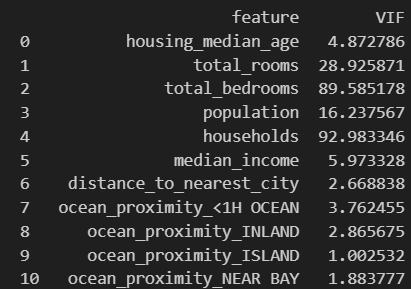 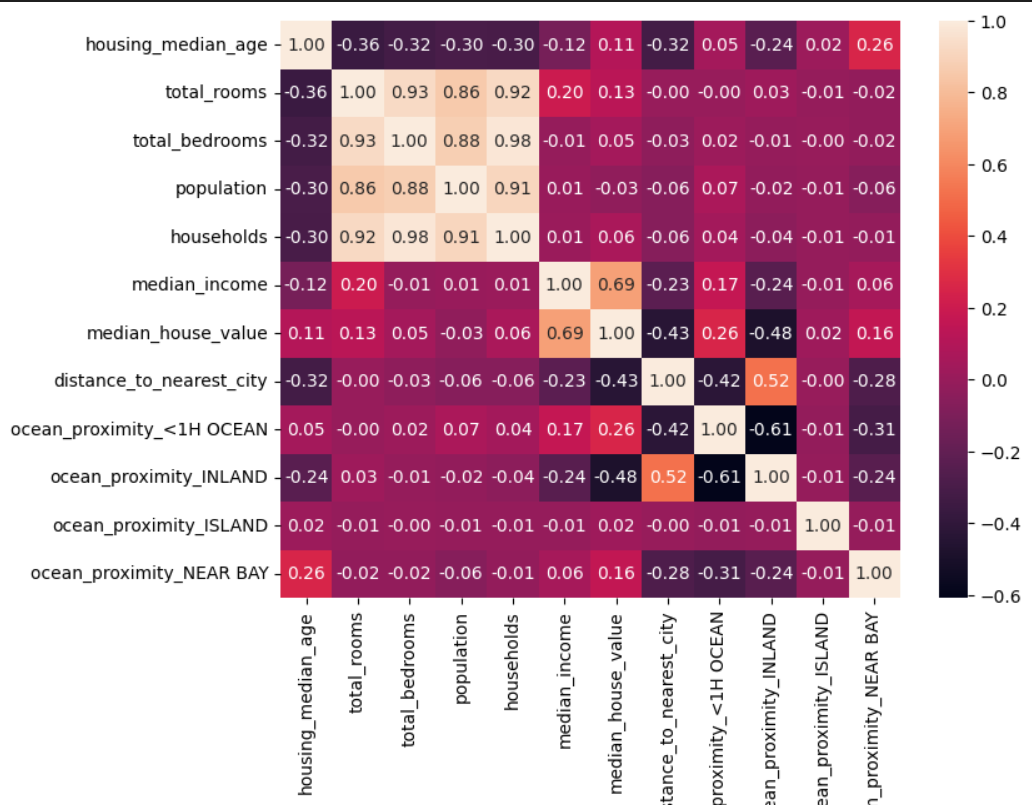

#### Options to do:
- drop "total_bedrooms" and preserve "total_rooms". Also drop "households" and preserve "population". And we can cosider to remove one encoded variable, for example one with highest VIF-test score "ocean_proximity_<1H OCEAN"
- we can combine variables: "rooms_per_household" = "total_rooms" /"households"
"bedroom_share" = "total_bedrooms" / "total_rooms", "population_per_household" = "population" / "households" (basically this would tell How many people live in an average household?)

### Distributions

#### Target variable (median_house_value) distribution. Not a normal distribution.
- Most houses are clustered between 100,000–250,000.
- we can seee a huge spike at 500,001, probably the “luxury” tail of the price distribution is compressed into one single value. Actually, the dataset hides the true prices of expensive houses. This is bad for ML model because a model will never predict values much higher than 500,001

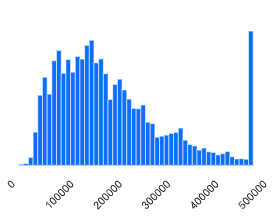

#### Fix options:
- use quantiles to remove the top % in order to get closer to normal distribution
- Offered but ChatGPT: Log transformation, Winsorization (capping extreme values instead of deleting), Robust scaling (for ML models), Box–Cox or Yeo–Johnson transformations

#### Support variable distributions
- housing_median_age: similar to target variable. We can see a large spike at the right edge (age = 52). That bump means many houses have a "housing median age" of 52, which is the maximum possible value_ probable all house_median ages > 52 years were capped at 52.<br>
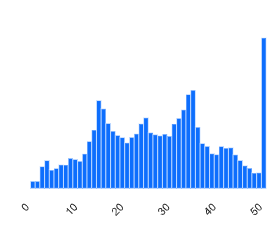
- total_rooms, total_bedrooms, population and households variable have a long tail. Earlier I suggested to drop some of these variables or to combine. The tail probable still will exist even with combined/new variables. That long tail is not good for ML models, it would be better to compresses the right tail and makes the distribution more normal-like.<br>

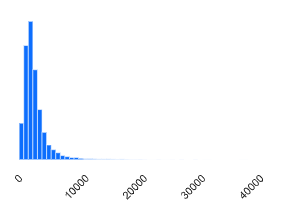 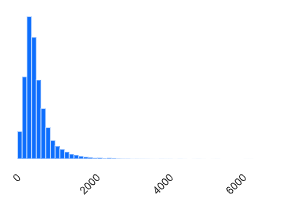<br>
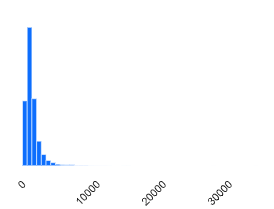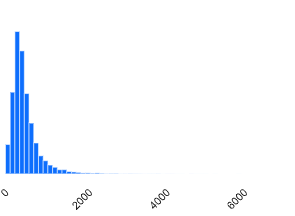<br>
- distance_to_nearest_city (this variable was created from lon, lat variables): most observations are very close to a city; most values are very close to a city (0–100); the tail gradually thins out, meaning most areas are urban or suburban. To make distibution better can be used Log-transform, Square-root transform Quantile transformation or many other technics as suggested by CharGPT.<br>
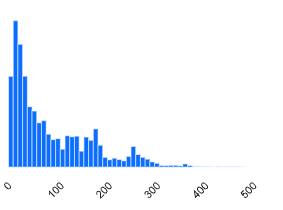
- median_income: has strong correlations with target variable. As areas with higher household income tend to have significantly higher house prices. Distribution is not that bad but still has a tail meaning many moderate-income areas and fewer high-income ones. A tail representing a small number of very high-income districts. ChatGPT suggest to keep as it is and use tree-based models (RandomForest, XGBoost, etc.) that handle mild skew fine. Or use Log-transform method ot other.<br>
 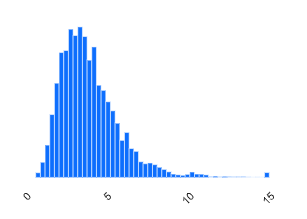

### Data imbalances
##### Variaables "total_rooms", "total_bedrooms", "population", "households" are imbalanced due to a long tails. Majority of data is in the low value range. A few values are very large, that's why we see these long tails.<br>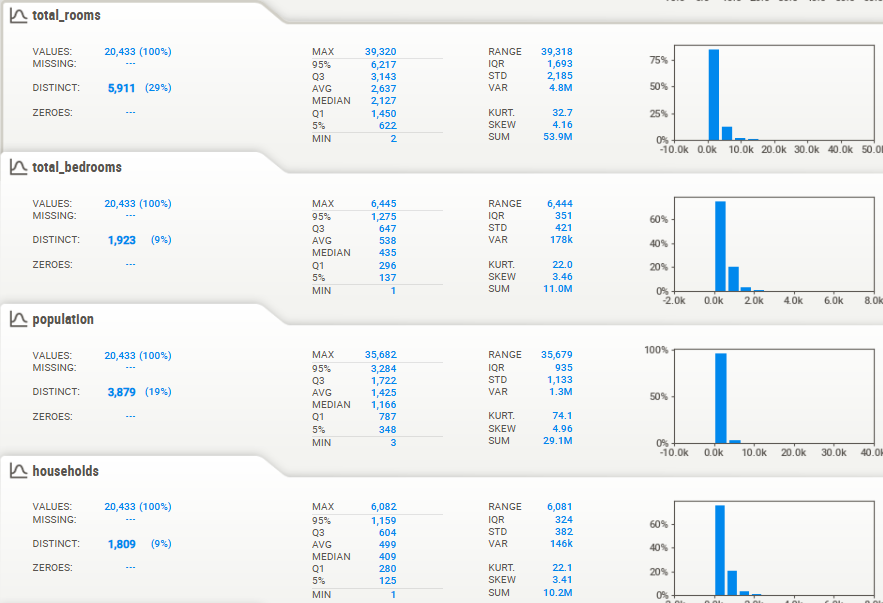
##### Fix options:
- As it was said is it good to combine these variables or to delete some, then the distribution will be still imbalanced, so it will be needed to remove high value outliers using quantile filtering
- Under-/oversampling techniques + synthesize will not work because there we have not so many high values that create long tail. If we do the data will have too many unrealistic synthetic values. <br>
##### median_house_value - target variable. High-value homes are underrepresented.<br>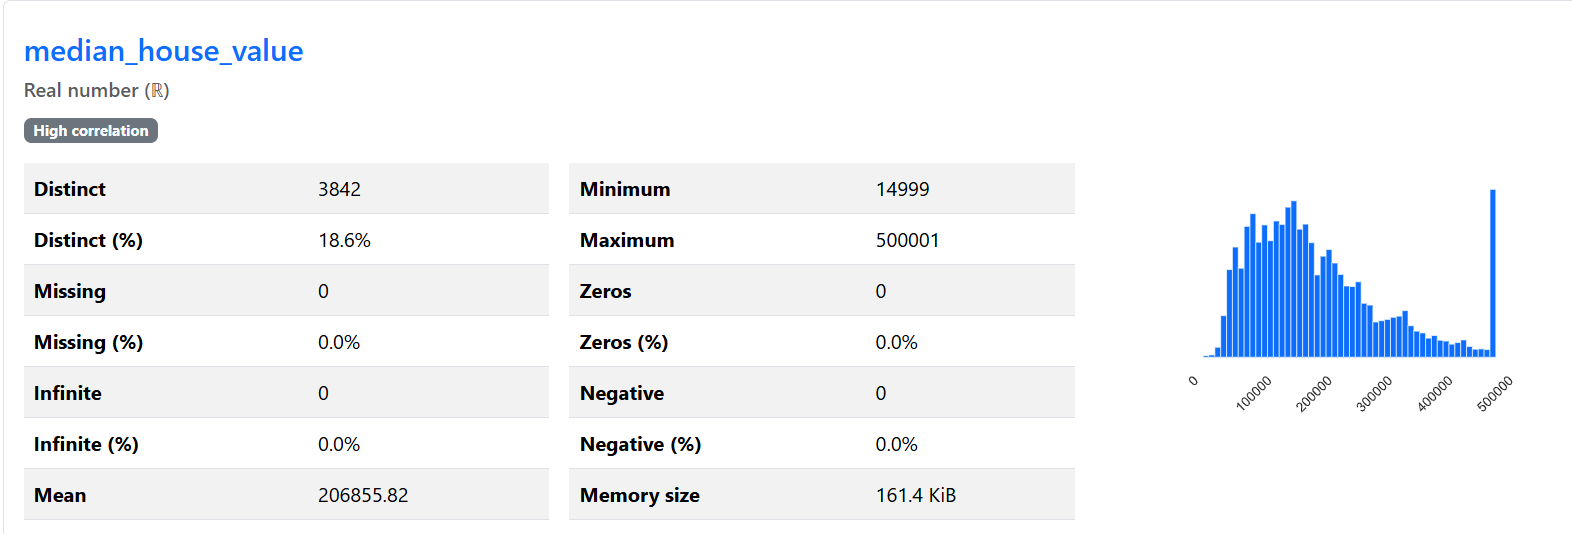
Fix option: 
- Consider quantile filtering<br>
##### housing_median_age variable has the same problem as target variable. I would fix it using the same method as target variable.<br>
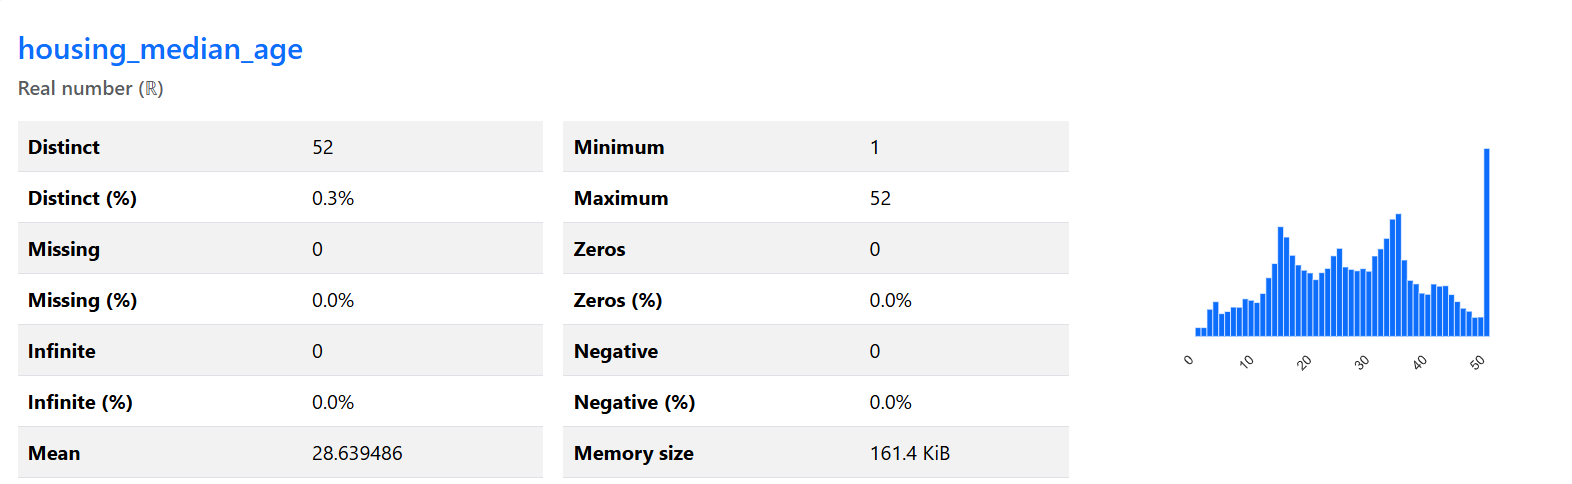<br>
##### ocean_proximity (categorical). Bar chart shows imbalance in categories: <1H OCEAN dominates and ISLAND is very rare. Rare categories may be ignored by the model<br>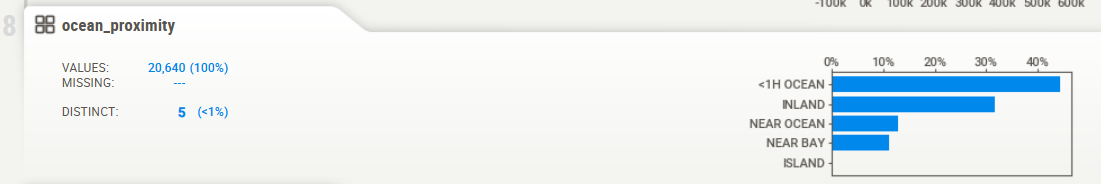
##### Option to fix:
- One-hot encode
- Good to check if rare classes skew results or introduce variance
- maybe consider grouping rare classes
##### distance_to_nearest_city.Very high concentration on the left (close distances (0–100) dominate), far distances are rare but present.<br> 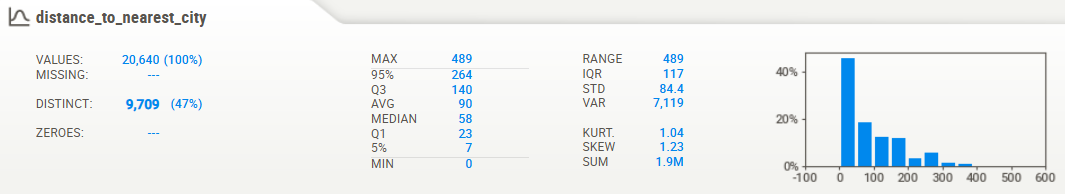
##### Options to fix:
- Log-transform
- Binning
- Winsorization <br>
##### These was offered by ChetGPT

###  Noise and outliers
#### The target variable (median_house_value) has a sharp jump and stops at $500,000, meaning that all more expensive houses are grouped at that same value. Other variables like: total_rooms, population, households, total_bedrooms, median_income  show highly skewed distributions with long right tails. It was found in data imbalance check and the same outcome will be in noise and outliers check. Because of that, I will apply quantile filtering to the target and selected input variables to reduce the impact of extreme values. After that i will check the data for noise for outliers using MAD as the algorithm.
#### MAN method found 997 rows of noise for "median_income" variable out of 18322 rows of data.<br>
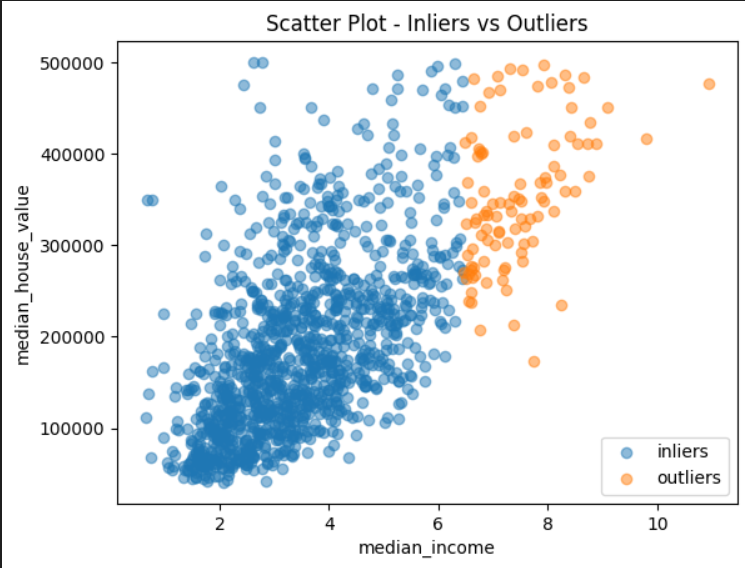<br>Outliers are mostly in the upper-right corner. Transformation (log-transform) might be applied as it will reduces right skew, compresses large values. We can also drop the most extreme values, for example 1 or 2% of median_income. We cannot drop all ourliers as they are not necessarily incorrect, but rather rare and they might be usefull in prediction.
#### Isolation Forest approach, we only find 92 outliers. Visualization:<br>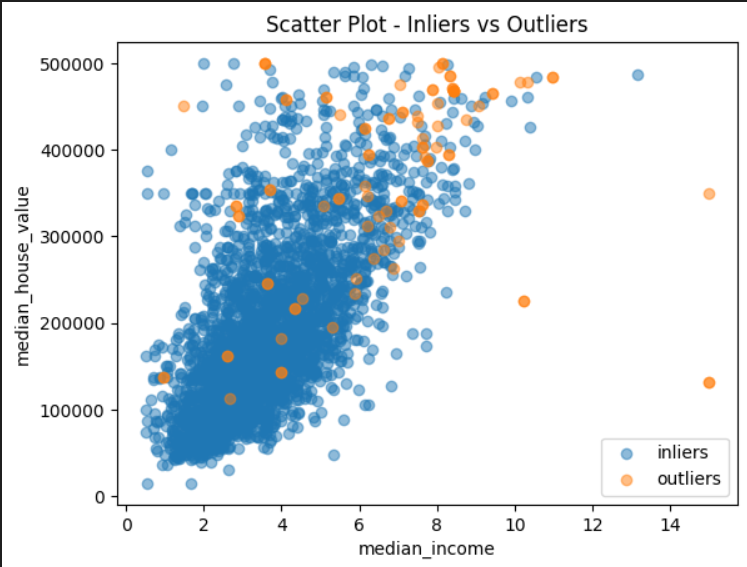<br>Here we can see that outliers scattered across multiple areas not only in the upper-right corner. Here is also some with low income but high price. Also far-edge points visible.
####  Elliptic Envelope approach found the same number of outliers as Isolation Forest.<br>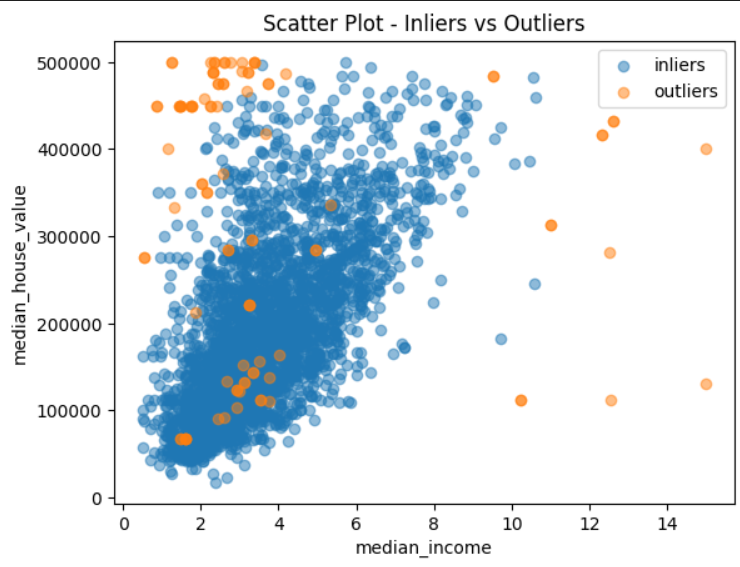
#### Shows outliers on both ends of the distribution: Low-income + high house price; High-income + low house price; Unusual points far from the dense center. 
#### Possible to delete 92 outliers as a noise that can  improve model accuracy.
#### 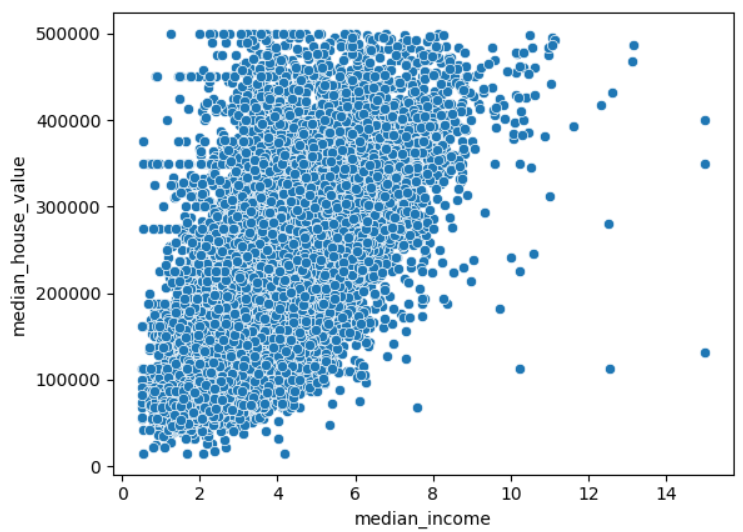br>
- Here we can see high-income outliers: Values between 10 and 15+, which are extremely rare. 
- There are also outliers with low price but high income.
- There are a lot of houses with high price but low income (probably these houses in high-coast-value locations)

### Lime and Shap
#### Shap<br>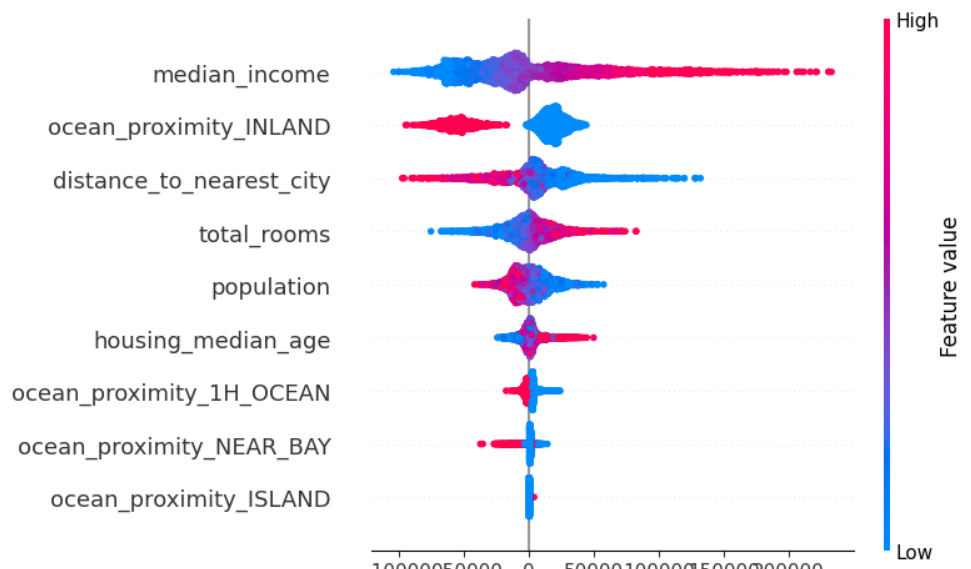<br>
#### The findings of Shap show the similar finding what I found above:<br>
- median income has the strongest affect on target variable. Higher income areas have higher housing values<br>
- ocean_proximity_INLAND affects the price too. Being far from the coast means lower property value.<br>
- distance_to_nearest_city. Closer to a city increases value.<br>
- total_rooms. Amount of room matters, but much less than income or location.<br>
- other variables have less influence on price

#### Lime<br>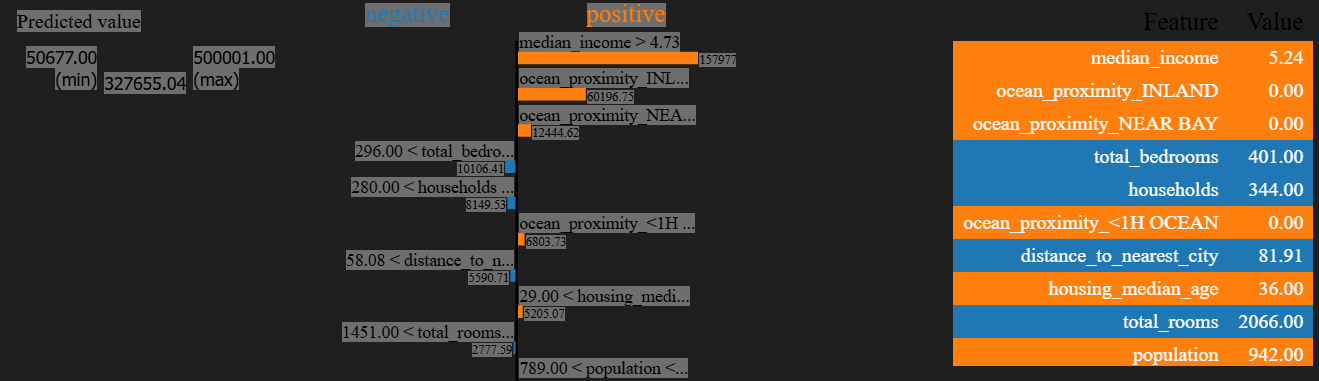<br>
#### The most impactful variables of positive and negative contributions:<br>Positive contribution: median income, ocean_proximity_INLAND, ocean_proximity_NEAR BAY<br>Negative contribution: total_bedrooms, households<br>
- median income: median_income > 4.73 — huge positive impact (+157977)<br>
- ocean_proximity_INLAND: 0 - positive impact (+60196), meaning the house is not inland have positive impact on price<br>
- ocean_proximity_NEAR BAY: 0 -  positive impact (+12444), meaning if the houses not near bay -  the prediction increases. Near bay means being near ocean, so I think lime tells apposite because of this variable was encoded and it looks on some specific rows. If we analyse globally the data ocean_proximity_NEAR BAY should have positive affect on price.<br>
- total_bedrooms: 296.00 < total_bedrooms <= 435.00. If amount of bedrooms in this range - the price of house will be lowered<br>
- households:280.00 < households <= 410.00. Households in this range are lowering value of houses. Maybe be because it considers as a overcrowded areas






### Overall trends and irregularities<br>
#### To see irregulations i am binning the price of houses into categorical value:<br>
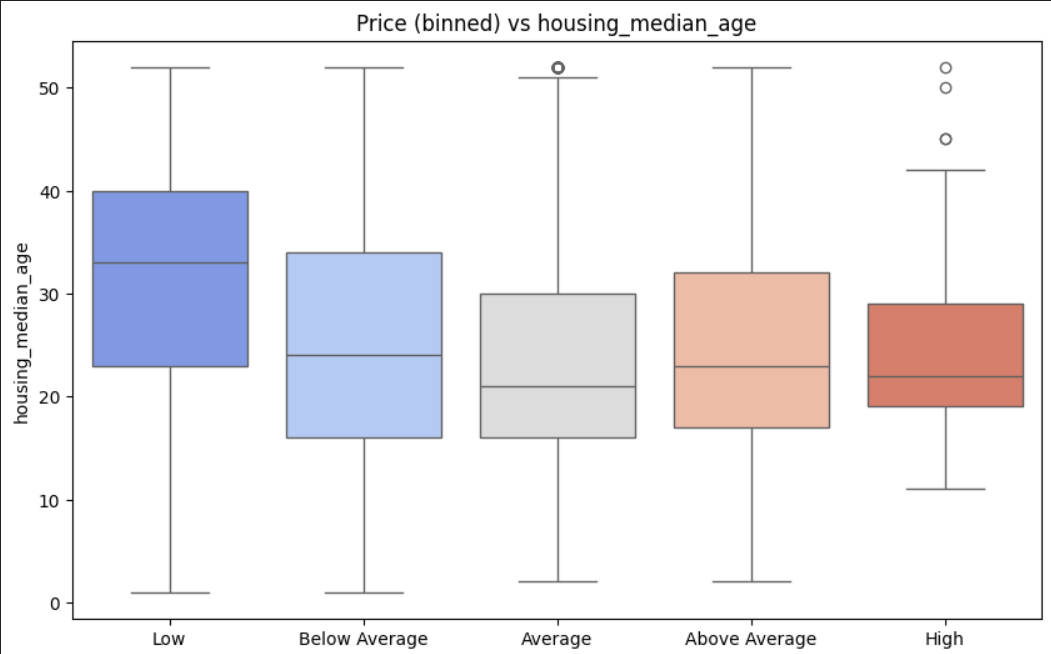<br>
- Low-priced areas tend to have older houses
- High-priced bin shows very old houses as outliers (maybe some historical valued houses)<br>
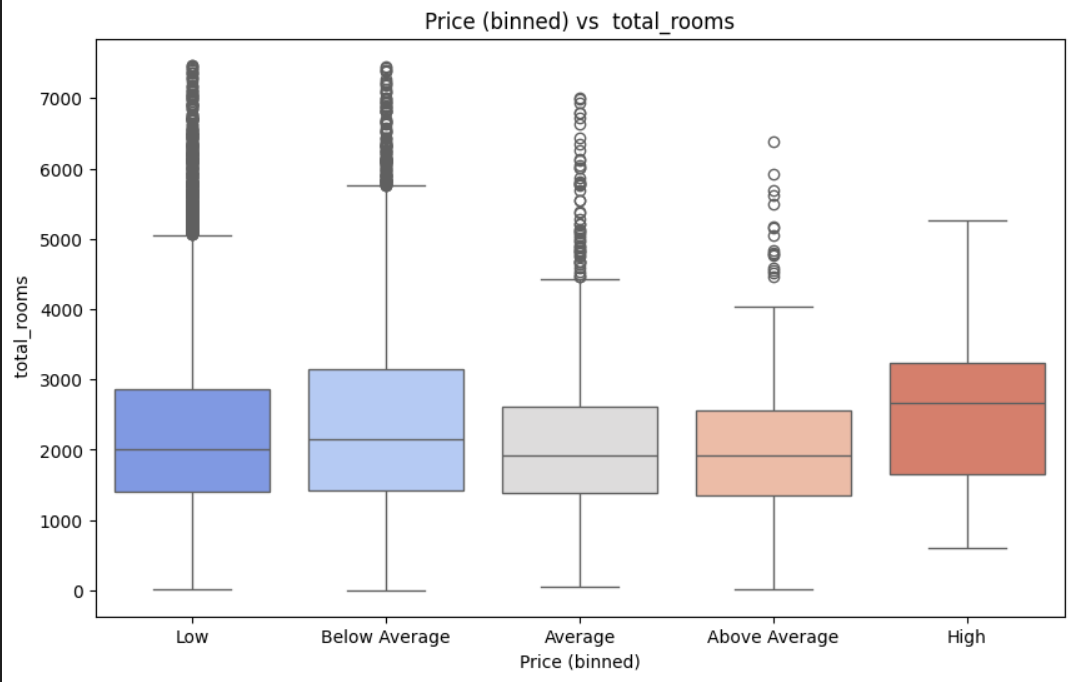<br>
- it looks like total_rooms has noisy impact, a lot of outliers (rooms > 5000) on avarage price and below average price bin than higher price bins. Maybe because of cheap land, huge houses in inland and beause of rural areas have very large properties but low prices.<br>
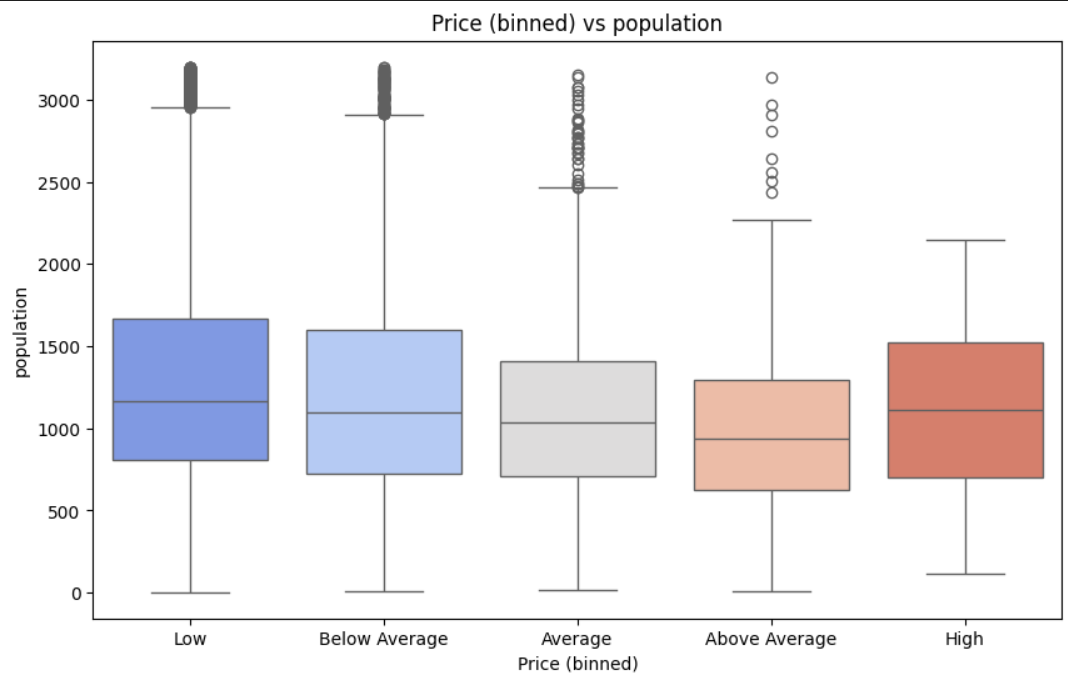<br>
- “Below Average” and “Average” price bins have extremely large population outliers
- Expensive areas tend to be less densely populated


### Summary of key points:<br>
- median_income. The strongerst support variable for the target variable. Low-income areas tend to have cheaper homes, except coastal low-income zones, where location outweighs income. Outliers exist mainly for high values of median_income. Or low income but very high price. I would keep outliers  as they represent real coastal cases.
- Ocean Proximity.  NEAR OCEAN, NEAR BAY, 1H OCEAN - increase house value, INLAND - strongly decreases price. One-hot encoding creates conflicting in Lime and Shap and possible noise. CAn be considered to merge NEAR OCEAN, NEAR BAY, 1H OCEAN.
- distance_to_nearest_city. Very high concentration on the left (close distances (0–100) dominate), far distances are rare but present. Exists outliers - houses far from city but still high-value. Consider to cut top 1% to reduce extreme outlier distances.
- Housing Median Age. Distribution is wide, age is not strictly correlated with price. There is a large spike at the right edge (age = 52) that possible to cut using quantiles.
- Based on multicollinearity + redundancy suggested to drop "total_bedrooms" and preserve "total_rooms", also drop "households" and preserve "population". Or, if that will not work well possible to combine variables: "rooms_per_household" = "total_rooms" /"households"
"bedroom_share" = "total_bedrooms" / "total_rooms", "population_per_household" = "population"